# Production et analyse des données


In [1]:
import pandas as pd

import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"



In [3]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/anonymous_answer_2026-07-24.csv", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")

#list_affil = pd.read_csv("../list_affiliation.csv", sep =",")
df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])]#.merge(list_affil, on = ["q45_clé", "q44_ufr_labo"], how = "left")

In [4]:

df_col = pd.read_csv("../../le_questionnaire/dico_variable.csv", sep = ",")


In [5]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [6]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";","|") ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [7]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [8]:
def tab_croise(data, x, y, regroup_y = True, khideux = False, norm=False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=norm)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=norm)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [9]:
df_col["question_family"] = df_col.label.apply(lambda row : row.split("_")[0])

dict_question = dict(zip(df_col.label.loc[df_col.label.isin(list_nominal_simple)], df_col.question_family.loc[df_col.label.isin(list_nominal_simple)]))



## Types de données produites

Les personnes interrogées travaillant exclusivement avec des données dites "quantitatives" sont 16% ({numref}`quali_or_quanti`). Elles sont 48% à s'appuyer essentiellement sur des données qualitatives et 36% à manipuler les deux types de données.

```{table} Données qualitatives ou quantitatives ?
:name: quali_or_quanti

|                           |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47,9 |
| Des données quantitatives |   19 | 16,0 |
| Les deux                  |   43 | 36,1 |
|Total               |119   | 100,0|
```

Les quatre types de données les plus fréquemment produites ({numref}`type_donnee_quali`) sont les entretiens (61%), les données textuelles ou documentaires (58%), les données d'enquête (53%) et les données expérimentales ou d'observation (52%). On notera toutefois le caractère ambigü de certaines catégories. Ainsi la notion d'"enquête" est largement utilisée en sciences sociales pour désigner la partie empirique des recherches et peut renvoyer aussi bien aux méthodes d'enquête ethnographique qu'aux méthodes d'enquête par questionnaire. De même, les données d'observation peuvent se comprendre au sens de l'anthropologue qui observe les interactions au sein d'un groupe humain  ou de l'ornithologue qui compte les espèces d'oiseau. Parmi les "autres types de données", une personne a d'ailleurs précisé qu'il s'agissait d "observations in situ non expérimentales". Tandis qu'une autre ne se reconnait pas dans la notion de "données".


```{figure} ./viz/type_donnee_quali.png
:name: type_donnee_quali

Les types de données traitées
```


In [10]:
quali_or_quanti = grouped_question(df0, column="q11_quali_or_quanti", index = "q45_clé")
print(quali_or_quanti[["q11_quali_or_quanti","nb","freq"]].to_markdown(index=False))


df_exp, type_data = split_multiple_choices(df0, column="q10_type_data", index="q45_clé", sep = '|')
print("\n### Dépôt dans Octaviana détaillé \n", type_data.to_markdown())

| q11_quali_or_quanti       |   nb |    freq |
|:--------------------------|-----:|--------:|
| Des données qualitatives  |   57 | 47.8992 |
| Des données quantitatives |   19 | 15.9664 |
| Les deux                  |   43 | 36.1345 |

### Dépôt dans Octaviana détaillé 
 |    | q10_type_data                           |   nb |   total |     freq |   total_freq |
|---:|:----------------------------------------|-----:|--------:|---------:|-------------:|
|  0 | Données d'entretien                     |   73 |     119 | 61.3445  |          100 |
|  1 | Données textuelles ou documentaires     |   69 |     119 | 57.9832  |          100 |
|  2 | Données d'enquête                       |   63 |     119 | 52.9412  |          100 |
|  3 | Données expérimentales ou d'observation |   62 |     119 | 52.1008  |          100 |
|  4 | Données statistiques                    |   47 |     119 | 39.4958  |          100 |
|  5 | Données multimédia                      |   22 |     119 | 18.4874  |        

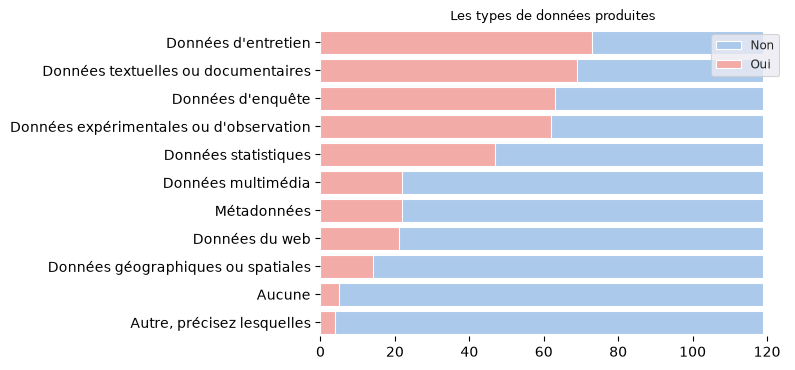

In [11]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_theme(context="paper",palette="pastel")

col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [12]:
col= "q10_type_data"
df_exp, gb_data = split_multiple_choices(df0, column=col, index="q45_clé", sep = '|')
df_exp.q10_type_data

0      Données expérimentales ou d'observation
0                          Données d'entretien
0          Données textuelles ou documentaires
0                           Données multimédia
1                                  Métadonnées
                        ...                   
117                             Données du web
117                       Données statistiques
117                         Données multimédia
118    Données expérimentales ou d'observation
118        Données textuelles ou documentaires
Name: q10_type_data, Length: 402, dtype: object

In [13]:
i = -1
for x in df_exp.q10_type_data:
    i += 1
    dtmp = df_exp[["q45_clé","q10_type_data","q11_quali_or_quanti"]].loc[df_exp.q10_type_data==x]
    
    dtmp1 = dtmp.groupby(["q10_type_data","q11_quali_or_quanti"]).agg(nb =("q45_clé", "size")).reset_index()
    dtmp1.loc[dtmp1.q11_quali_or_quanti=="Des données quantitatives", "order"]=2
    dtmp1.loc[dtmp1.q11_quali_or_quanti=="Des données qualitatives", "order"]=1
    dtmp1.loc[dtmp1.q11_quali_or_quanti=="Les deux", "order"]=0
    dtmp1 = dtmp1.sort_values("order", ascending=True)
    dtmp1["freq"] = dtmp1.nb/119*100
    dtmp1["total"] = np.sum(dtmp1.freq)
    dtmp1["cum_sum"] = np.cumsum(dtmp1.freq)

    if i==0:
        q10_data = dtmp1.copy()
    else:
        q10_data = pd.concat([q10_data, dtmp1])

q10_data = q10_data.sort_values(["total","order","cum_sum"],  ascending=[False, False, False])

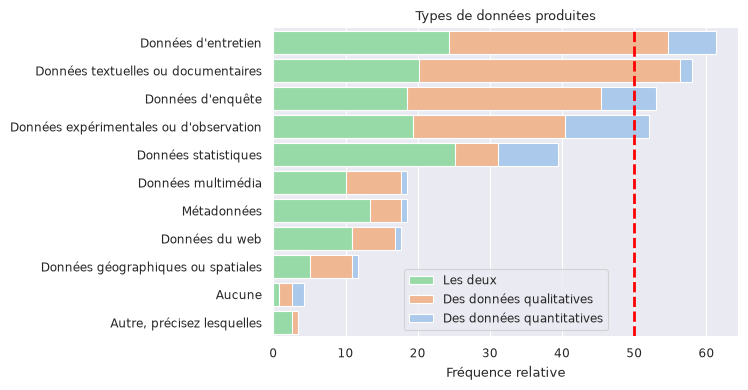

In [14]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(context="paper", palette="pastel")

   
g = sns.barplot(x="cum_sum", y="q10_type_data", data=q10_data, hue="q11_quali_or_quanti", dodge=False)

titre = "Types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set(xlabel='Fréquence relative')
ax.axvline(x=50, color="red", linestyle="--", linewidth=2)
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot

ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])



sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/type_donnee_quali.png", bbox_inches='tight', dpi = 300)

## Autres types de données

In [15]:
for x in df0.q10_other_type_data.loc[~df0.q10_other_type_data.isna()]:
    print(x)

Observations in situ non expérimentales
Images
données orales, multimodales et visuo-gestuelles
pourquoi ce terme de "données" hérité des sciences dures et qui ne recoupe pas le travail dans la plupart des humanités ou dont je n'ai pas envie de me servir pour décrire ma recherche + désambiguisez tous les acronymes cf TGIR


In [16]:
i=-1
for x in df_col.label.loc[(df_col.question_family=="q5")& ((~df_col.label.str.contains("q5_1"))&(~df_col.label.str.contains("rec"))&(~df_col.label.str.contains("family")))]:
    i+=1
    gb_data0 = grouped_question(df0, column=x, index = "q45_clé")
    gb_data = gb_data0.loc[gb_data0[x]=="Oui"]
    gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
    
    if i == 0:
        gb_q5 = gb_data.drop(columns=[x])#.copy()
    else:
        gb_q5 = pd.concat([gb_q5, gb_data.drop(columns=[x])])


/tmp/ipykernel_6173/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_6173/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gb_data.loc[gb_data[x]=="Oui", "logiciel_traitement"] = x.replace("q5_","")
/tmp/ipykernel_6173/2686485856.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

## Outils de traitement



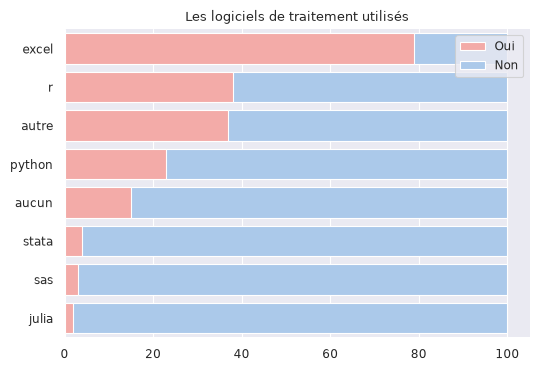

In [17]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,4))

# Plot the total crashes
sns.set_color_codes("pastel")

col = "logiciel_traitement"
sns.barplot(x="total_freq", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_q5.sort_values("nb", ascending=False),
            label="freq", color="r", ax=ax)
titre = "Les logiciels de traitement utilisés"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [1,0]

#add legend to plot

ax.legend([handles[idx] for idx in order],["Oui","Non"])
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/logiciel_traitement.png", bbox_inches='tight', dpi = 200)

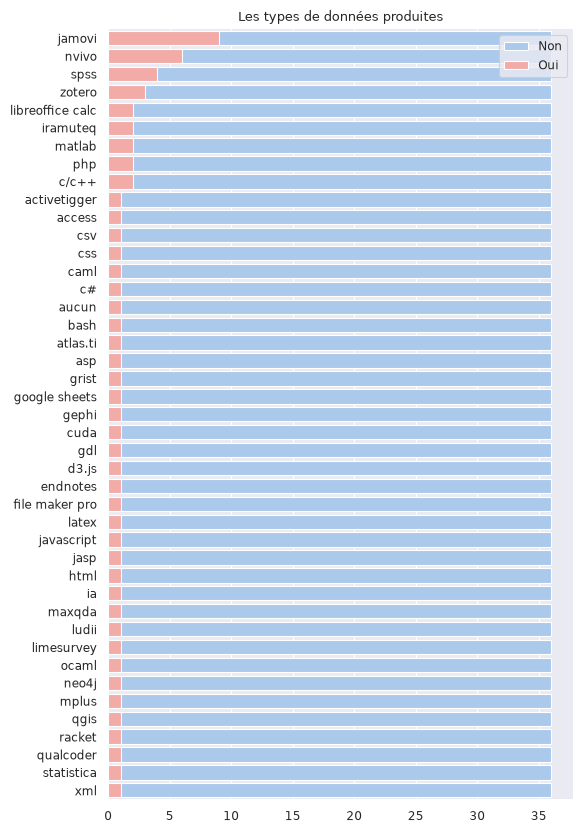

In [18]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(6,10))

# Plot the total crashes
sns.set_color_codes("pastel")

q5_1 = df0.loc[~df0.q5_1_other_lang_rec.isna()]
col= "q5_1_other_lang_rec"
df_exp, gb_data = split_multiple_choices(q5_1, column=col, index="q45_clé", sep = '|')
sns.barplot(x="total", y=col, data=gb_data,
            label="Non", color="b", ax=ax)
sns.barplot(x="nb", y=col, data=gb_data,
            label="Oui", color="r", ax=ax)
titre = "Les types de données produites"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
#plt.savefig(f"viz/type_donnee.png", bbox_inches='tight', dpi = 200)

In [19]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/type_of_software.csv", "r") as file_in:
    type_logi = pd.read_csv(file_in, sep=",")

type_logi.columns
family_logi = dict(zip(type_logi.q5_logiciel_traitement_rec, type_logi.q5_family_logi))

In [20]:
gb_q5["q5_family_logi"]= gb_q5.logiciel_traitement.map(family_logi.get)
gb_q5.loc[gb_q5["logiciel_traitement"]=="aucun", "q5_family_logi"] = "aucun"
gb_q5.loc[gb_q5["logiciel_traitement"]=="autre", "q5_family_logi"] = "autre"

df_exp, gb_data = split_multiple_choices(df0.loc[~df0.q5_1_other_lang_rec.isna()], column='q5_1_other_lang_rec', index="q45_clé", sep = '|')

df_exp["q5_family_logi"]= df_exp.q5_1_other_lang_rec.map(family_logi.get)
df_exp2 = df_exp.loc[~df_exp.q5_1_other_lang_rec.isin(["aucun","autre"])]


In [21]:
gb_data = df_exp2.groupby(["q5_family_logi", "q5_1_other_lang_rec"]).agg(nb=("q45_clé","size")).sort_values(["nb"], ascending=[False]).reset_index()
gb_data["freq"] = gb_data.nb/119*100

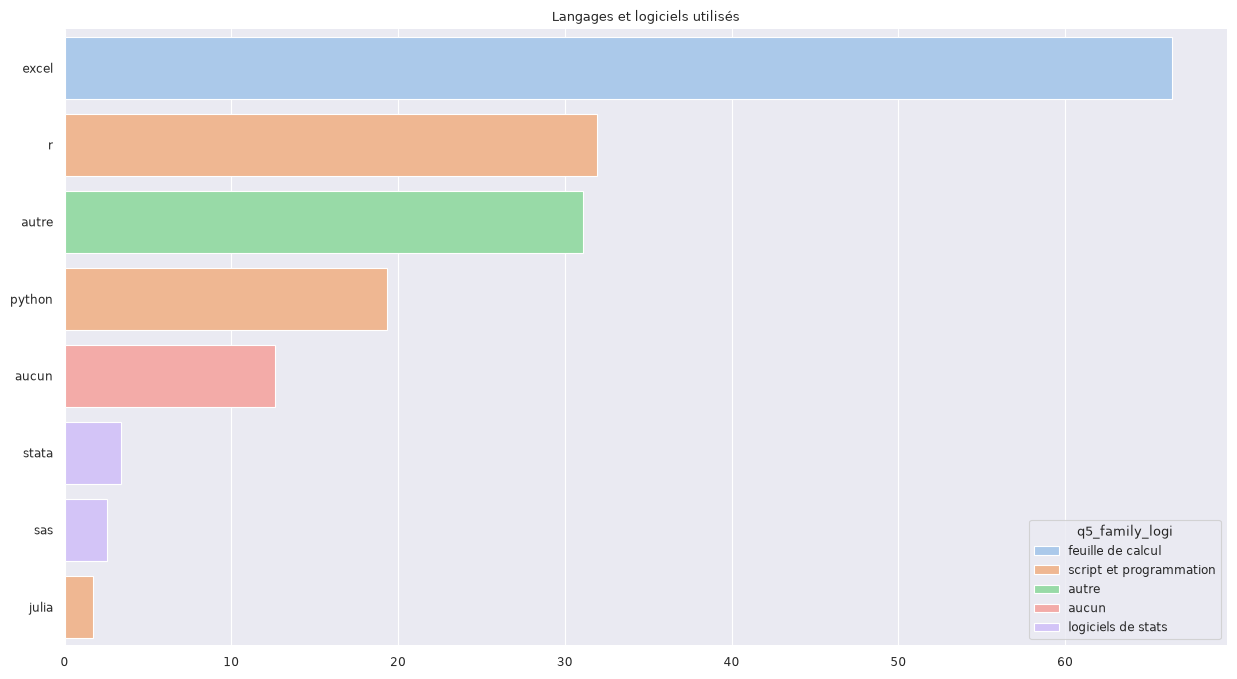

In [22]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(15,8))

# Plot the total crashes
sns.set_color_codes("pastel")


col = "logiciel_traitement"

sns.barplot(x="freq", y=col, data=gb_q5.sort_values("nb", ascending=False), hue="q5_family_logi")
titre = "Langages et logiciels utilisés"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))


sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/logiciel_used_question_5.png", bbox_inches='tight', dpi = 200)

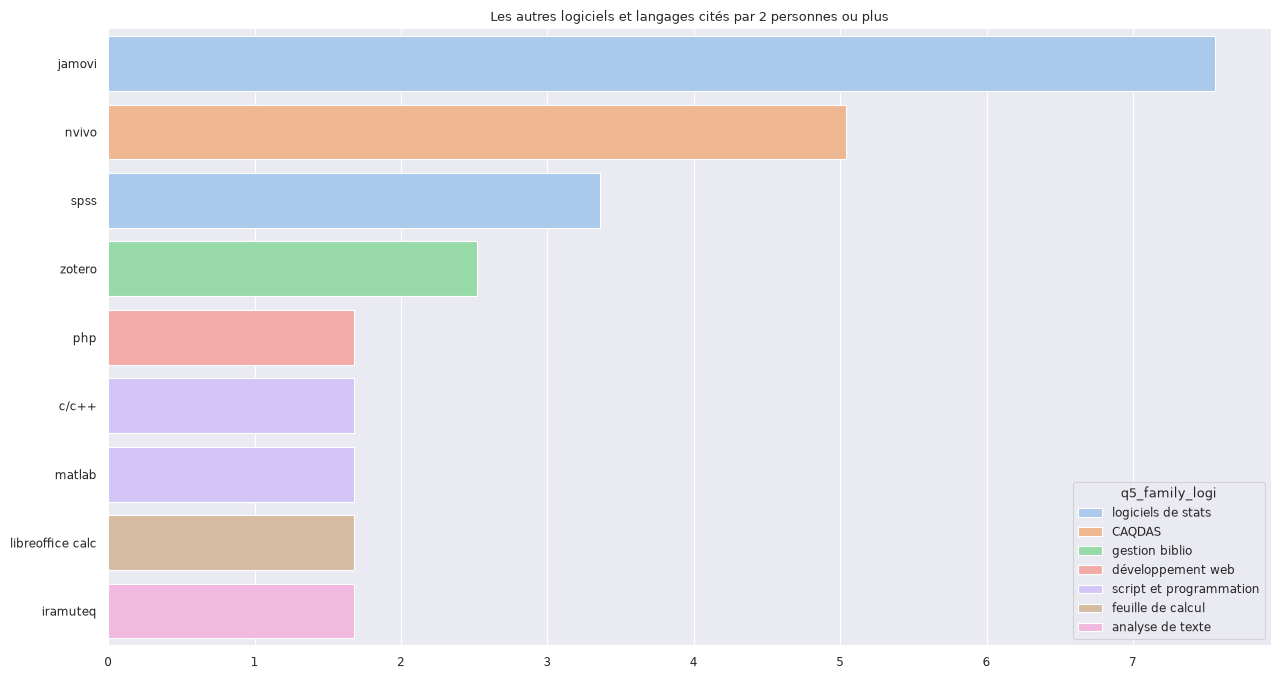

In [23]:
# Initialize the matplotlib figure
fig, ax = plt.subplots(1, figsize=(15,8))

# Plot the total crashes
sns.set_color_codes("pastel")



gb_data2 = gb_data.loc[gb_data.nb>1]
sns.barplot(x="freq", y="q5_1_other_lang_rec", data=gb_data2,
            hue="q5_family_logi")
titre = "Les autres logiciels et langages cités par 2 personnes ou plus"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
    

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/logiciel_traitement_cited_by_2people.png", bbox_inches='tight', dpi = 200)

In [24]:
gb_data

,q5_family_logi,q5_1_other_lang_rec,nb,freq
0,logiciels de stats,jamovi,9,7.563025
1,CAQDAS,nvivo,6,5.042017
2,logiciels de stats,spss,4,3.361345
3,gestion biblio,zotero,3,2.521008
4,développement web,php,2,1.680672
5,script et programmation,c/c++,2,1.680672
6,script et programmation,matlab,2,1.680672
7,feuille de calcul,libreoffice calc,2,1.680672
8,analyse de texte,iramuteq,2,1.680672
9,CAQDAS,maxqda,1,0.840336


Le graphique ({numref}`logiciel_used_question_5`) donne à voir les réponses à la question "Quels langages de programmation ou logiciels de traitement de données utilisez-vous ?". 66% des personnes interrogées utilisent Excel. On retrouve ensuite les langages R (32% des répondants) et Python (19%). Les logiciels de statistique Stata (3%) et SAS (3%), ainsi que le langage Julia (2%) sont plus confidentiels. On remarque par ailleurs que 31% des répondants ont recourt à d'autres outils que ceux proposés dans la question.



```{figure} ./viz/logiciel_used_question_5.png
:name: logiciel_used_question_5

Quels langages de programmation/logiciels de traitement de données utilisez-vous ?
```

Ces répondants ont complété leur réponse en donnant le nom de ces autres langages et logiciels. En tout, 26 outils ont été cités. Nous les avons regroupé en sept "familles":

1. les "logiciels de statistiques" comme SPSS, Jamovi, Stata ;
2.  les langages de "scripts et de programmations" comme Matlab ou C++. Probablement qu'une subdivision de cette catégorie serait justifiée afin de distinguer les langages généralement employés pour l'analyse de données (R, Julia, Matlab, Python) et les langages de programmation comme C++ ;
3.  les outils de gestion de bibliographie (Zotero, Endnote) ;
4.  les logiciels de "tableurs" et les feuilles de calculs : Excel, Libre Calc ;
5.  les langages liés au développement web (css, html, php, javascript) ;
6.  les outils d'analyse textuelle (Iramuteq, ActiveTigger) ;
7.  les "CAQDAS" (Computer-Assisted Qualitative Data Analysis Software) comme Nvivo, Qualcoder, Atlas.ti

Sur le graphique ci-dessous {numref}`logiciel_traitement_cited_by_2people`, nous n'avons affiché que les programmes cités par deux personnes au moins. Jamovi (8%) est le plus utilisé. Il s'agit d'un logiciel d'analyse statistique open source à la différence de SPSS qui est propriétaire. SPSS est cité par 3% des répondants. comme Nvivo (N=6) pour les logiciels CAQDAS. 

On note enfin que 13% des personnes interrogées disent n'utiliser aucun outil informatique pour traiter les données.

```{figure} ./viz/logiciel_traitement_cited_by_2people.png
:name: logiciel_traitement_cited_by_2people

Logiciels cités par deux répondants ou plus.
```




## Développement et dépôt de codes ou de logiciels

In [25]:
dev_code= grouped_question(df0, column="q6_dev_code", index = "q45_clé")
print(dev_code.to_markdown(index=False))

df_exp, sw_depot2 = split_multiple_choices(df0, column="q7_software_depot", index="q45_clé", sep = '|')
print("\n### Ouverture du code \n", sw_depot2.to_markdown(index=False))

| q6_dev_code   |   nb |   total |    freq |   total_freq |
|:--------------|-----:|--------:|--------:|-------------:|
| Non           |   87 |     119 | 73.1092 |          100 |
| Oui           |   32 |     119 | 26.8908 |          100 |

### Ouverture du code 
 | q7_software_depot          |   nb |   total |      freq |   total_freq |
|:---------------------------|-----:|--------:|----------:|-------------:|
| Non                        |   89 |     119 | 74.7899   |          100 |
| Oui, sur GitHub            |   23 |     119 | 19.3277   |          100 |
| Oui, sur GitLab            |   12 |     119 | 10.084    |          100 |
| Oui, autre, précisez       |    6 |     119 |  5.04202  |          100 |
| Oui, sur Software Heritage |    1 |     119 |  0.840336 |          100 |


In [26]:
df0.loc[df0.q7_software_depot =="Non", "open_code"] = False
df0.loc[df0.q7_software_depot!="Non", "open_code"] = True

dev_code= grouped_question(df0, column="open_code", index = "q45_clé")
#print(dev_code.to_markdown(index=False))

print(pd.crosstab(df0.open_code, df0.q5_r, margins=True, normalize="columns").to_markdown())

| open_code   |      Non |      Oui |      All |
|:------------|---------:|---------:|---------:|
| False       | 0.790123 | 0.657895 | 0.747899 |
| True        | 0.209877 | 0.342105 | 0.252101 |


Parallèlement  à l'utilisation d'outils informatiques pour le traitement des données, 27% des répondants ont déjà été amenés à développer ou faire développer du code ou des logiciels dans le cadre de leurs recherches. 

```{table} Les utilisateurs de langages informatiques ne développent pas tous du code. Le tableau indique que sur 51 personnes déclarant utiliser des langages de programmation (R, Python, C++, etc.), 26 considèrent qu'ils ne développent pas de code.
:name: dev_code_x_prog_tools

|               |   N'utilise pas de langage de programmation  |   Utilise des langages de programmation  |   Total |
|:--------------|--------:|-------:|------:|
| Ne développe pas de code           |      61 (51,26%)|     26 (21,85%) |    87 (73,11%)|
| Développe du code           |       7 (5,88%)|     25 (21,01%)|    32 (26,89%)|
| Total           |      68  (57,41%)|     51 (42,86%|   119 (100%)|
```

Sur les 32 personnes ayant répondu "Oui" à la question "êtes-vous amené.e à développer ou faire développer des logiciels/du code spécialisé(s) ?", 31 ont donné des indications sur ce qu'elles développent ou font développer ({numref}`dev_code_tab`). Après une analyse manuelle des réponses, nous en avons classé 15 (soit 48%  des 31 réponses) dans la catégorie "traitement et analyse de données". Sept exemples (23% des 31 réponses) concernent la collecte de données d'expérience via, par exemple, le logiciel Psytoolkit. Tandis que 8 répondants (26% des 31 réponses) parlent de logiciels variés, d'algorithmes, de plateformes sans préciser la finalité du code.


```{table} Types de code développé
:name: dev_code_tab

| Type de développement                  |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48,4 |
| programmes et logiciels variés   |    8 |      31 |   25,8 |
| collecte de données              |    7 |      31 |   22,6 |
| diffusion                        |    2 |      31 |    6,5 |
```


Il est intéressant de noter que le recours à un langage de programmation ne suffit pas pour se considérer comme "développeur". En effet, le tableau croisé {numref}`dev_code_x_prog_tools` montre que 26 des 51 répondants manipulant des langages de programmation ou des scripts (R, Python, C++) disent ne pas développer de code. Cette proportion est plus forte chez les utilisateurs de "R" que de Python. 63% des premiers ne développent pas de code contre 30% pour les seconds ({numref}`dev_code_x_R_python`).

```{table} Les utilisateurs de R et de Python et le développement de code
:name: dev_code_x_R_python

|                                   |Total  |N'utilise pas R | Utilise R |N'utilise pas Python |Utilise Python|
|:----------------------------------|------:|---------------:|----------:|--------------------:|-------------:|
| Ne développe pas de code          | 73,11 | 77,78          | 63,16     |  83,33              | 30,43        |
| Développe du code                 | 26,89 | 22,22          | 36,84     |  16,67              | 69,57        |
| Total                             |100,00 |100,00          |100,00     | 100,00              |100,00        |
```

En tout, 30  personnes — soit 25% des 119 participants à l'enquête et 94% des répondants développant du code — ouvrent leurs codes et logiciels quelque soit le mode d'ouverture choisi. Cette proportion est de 34%  chez les utilisateurs de R contre 70% pour Python {numref}`open_code_x_R_python`. Des chiffres similaires à ceux observés dans le tableau {numref}`dev_code_x_R_python`. Nous pouvons alors faire l'hypothèse que l'écart observé entre le recours aux langages informatiques et le développement de code est lié au fait pour les chercheurs de se sentir légitimes à ouvrir leurs scripts. 

```{table} Les utilisateurs de R et de Python et l'ouverture du code
:name: open_code_x_R_python

|                                   | Total |N'utilise pas R | Utilise R| N'utilise pas Python |Utilise Python|
|:----------------------------------|------:|---------------:|---------:|---------------------:|-------------:|
| Ne développe pas de code          | 74,79 | 79,01         | 65,79    |  85,42               | 30,43        |
| Développe du code                 | 25,21 | 20,99         | 34,21    |  14,58               | 69,57        |
| Total                             |100,00 |100,00         |100,00    | 100,00               |100,00        |
```

Si nous regardons maintenant comment les 30 répondants ouvrent leurs codes, on note que 77% d'entre eux (19% des personnes interrogées) ont déjà fait des dépôts sur Github et 40% (10% des personnes interrogées) sur des instances Gitlab. Ils sont par ailleurs 5% à utiliser d'autres solutions, en complément ou non des deux premières. Ces solutions sont :

* Le dépôt {term}`Statistical Software Components` (SSC) des commandes Stata;
* Les dépôts personnels;
* HAL;
* Ortolang et Huma-Num ;
* L'Institut national pour la propriété intellectuelle

```{table} Les modalités d'ouverture du code et des logiciels
:name: tab_software_depot

|    | q7_software_depot          |   Effectifs|   Total |  Fréquences relatives (%) |  
|---:|:---------------------------|-----------:|--------:|----------:|
|  0 | Non                        |         89 |     119 | 74,79     |
|  1 | Oui, sur GitHub            |         23 |     119 | 19,33     |
|  2 | Oui, sur GitLab            |         12 |     119 | 10,08     |
|  3 | Oui, autre, précisez       |          6 |     119 |  5,04  | 
|  4 | Oui, sur Software Heritage |          1 |     119 |  0,84 |
```




In [27]:
df_exp, gb_data1 = split_multiple_choices(df0.loc[~df0.q6_1_dev_group.isna()], column='q6_1_dev_group', index="q45_clé", sep = '|')
print(gb_data1.drop(columns=["total_freq"]).round(decimals=1).to_markdown(index=False))

| q6_1_dev_group                   |   nb |   total |   freq |
|:---------------------------------|-----:|--------:|-------:|
| traitement et analyse de données |   15 |      31 |   48.4 |
| programmes et logiciels variés   |    8 |      31 |   25.8 |
| collecte de données              |    7 |      31 |   22.6 |
| diffusion                        |    2 |      31 |    6.5 |


## Accompagnements et formations méthodologiques

### Méthodes

In [28]:
for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q18_stat_desc_help   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                  |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé          |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant        |   14 |     119 | 11.7647 |          100 |
|    | q18_regressions_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                    |   84 |     119 | 70.5882 |          100 |
|  1 | Oui, avancé            |   15 |     119 | 12.605  |          100 |
|  2 | Oui, débutant          |   20 |     119 | 16.8067 |          100 |
|    | q18_temporal_analysis_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                          |   81 |     119 | 68.0672 |          100 |
|  1 | Oui, avancé            

In [29]:
[col for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]]

['q18_stat_desc_help',
 'q18_regressions_help',
 'q18_temporal_analysis_help',
 'q18_cartographie_help',
 'q18_analyse_text_help',
 'q18_net_analysis_help',
 'q18_webscrapping',
 'q18_deeplearning_help',
 'q18_edit_num_help',
 'q18_questionnaire_help',
 'q18_bibliométrie_help']

In [30]:
dict_help_methode = {
    'q18_stat_desc_help':'Statistiques descriptives',
    'q18_regressions_help':'Régression',
 'q18_temporal_analysis_help':'Analyse de données temporelles',
 'q18_cartographie_help': 'Cartographie',
 'q18_analyse_text_help':'Analyse textuelle',
 'q18_net_analysis_help': 'Analyse de réseaux',
 'q18_webscrapping' : 'Webscrapping',
 'q18_deeplearning_help': 'Intelligence artificielle',
 'q18_edit_num_help': 'Edition numérique',
 'q18_questionnaire_help':"Construction d'un questionnaire",
 'q18_bibliométrie_help':'Bibliométrie'}

In [31]:

i=-1
for col in df_col.label.loc[(df_col.group=="10_help_methode")&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_methode[col]


    if i == 0:
        q18 = dftmp.copy()
    else:
        q18 = pd.concat([q18, dftmp])


In [32]:
q18_bis = pd.crosstab(q18.accomp_name, q18.interet_accomp, normalize="index").stack().reset_index(name='nb')
q18_ter = pd.crosstab(q18.accomp_name, q18.interet_accomp, normalize="index")
q18_ter = q18_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


q18_ter = q18_ter.merge(q18_bis, on=["accomp_name","interet_accomp"], how = "left")

In [33]:
q18_ter["cum_sum"]= q18_ter["cum_sum"]*100
q18_ter["nb"]= q18_ter["nb"]*100
for x in q18_ter.accomp_name.unique():
    non = q18_ter.nb.loc[(q18_ter.accomp_name==x) & (q18_ter.interet_accomp=="Non")]
    q18_ter.loc[q18_ter.accomp_name==x, "Oui"] = 1-np.sum(non)
q18_ter = q18_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q18_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
11,Intelligence artificielle,Non,100.000000,43.697479,-42.697479
10,Intelligence artificielle,"Oui, avancé",56.302521,15.966387,-42.697479
9,Intelligence artificielle,"Oui, débutant",40.336134,40.336134,-42.697479
2,Webscrapping,Non,100.000000,52.941176,-51.941176
1,Webscrapping,"Oui, avancé",47.058824,11.764706,-51.941176
0,Webscrapping,"Oui, débutant",35.294118,35.294118,-51.941176
26,Analyse textuelle,Non,100.000000,55.462185,-54.462185
25,Analyse textuelle,"Oui, avancé",44.537815,14.285714,-54.462185
24,Analyse textuelle,"Oui, débutant",30.252101,30.252101,-54.462185
29,Analyse de réseaux,Non,100.000000,60.504202,-59.504202


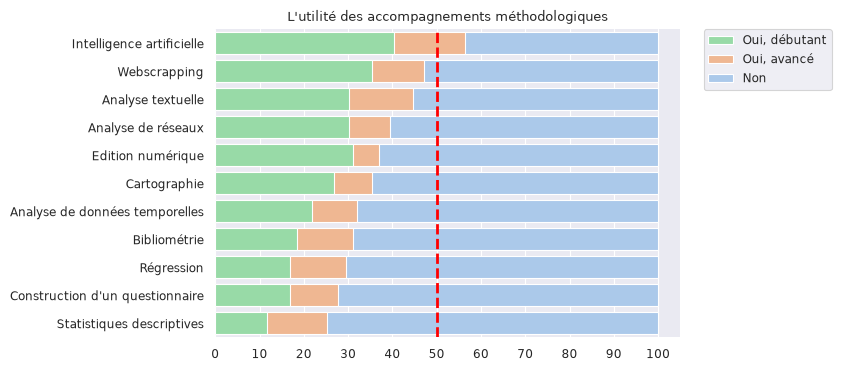

In [34]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(context="paper",palette="pastel")

   
g = sns.barplot(x="cum_sum", y="accomp_name", data=q18_ter, hue="interet_accomp", dodge = False)

titre = "L'utilité des accompagnements méthodologiques"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.set_xticks(ticks = [0,10,20,30,40,50,60,70,80,90,100])
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
ax.axvline(x=50, color="red", linestyle="--", linewidth=2)

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot


ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/10_help_methode.png", bbox_inches='tight', dpi = 200)

L'intelligence artificielle est la thématique pour laquelle un accompagnement est le plus demandé : 40% des répondants en ressentent le besoin à un niveau débutant et 16% à un niveau avancé. L'accompagnement à l'utilisation d'outils de webscrapping vient ensuite avec 47% des répondants qui le considèrent comme utile (35% à un niveau débutant et 12% à niveau avancé). Concernant, les méthodes spécifiques comme l'analyse textuelle et l'analyse de réseau, nous observons un taux identiques de personnes interrogées souhaitant un accompagnement à un niveau débutant. En revanche, la demande pour un accompagnement à l'analyse textuelle à un niveau avancé est un peu plus élevée (14%) que pour l'analyse de réseau.

En bas du tableau nous retrouvons le thème des statistiques descriptives avec 25% des répondants qui jugent utile un accompagnement sur ce sujet.


```{figure} ./viz/10_help_methode.png
:name: help_methode

Ressentez-vous le besoin d'un accompagnement méthodologique
```

### Outils

In [35]:
for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())



|    | q16_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   80 |     119 | 67.2269 |          100 |
|  1 | Oui, avancé        |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant      |   16 |     119 | 13.4454 |          100 |
|    | q16_logiciels_d'analyse_statistique_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                                        |   69 |     119 | 57.9832 |          100 |
|  1 | Oui, avancé                                |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant                              |   27 |     119 | 22.6891 |          100 |
|    | q16_python_help   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non               |   74 |     119 

In [36]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]]

['q16_tableur_help',
 "q16_logiciels_d'analyse_statistique_help",
 'q16_python_help',
 'q16_garg_iram_hyperbase_help',
 'q16_ocr_help',
 'q16_network_analysis_help',
 'q16_odette_atom_help',
 'q16_caqdas_help',
 'q16_carto_help',
 'q16_sig_help',
 'q16_sgbd_help',
 'q16_autre_help']

In [37]:
dict_help_outil1 = {
    'q16_tableur_help':'Tableur',
 "q16_logiciels_d'analyse_statistique_help":"Logiciels de stat",
 'q16_python_help':"Python",
 'q16_garg_iram_hyperbase_help':"Logiciels d'analyse textuel",
 'q16_ocr_help':"Logiciels d'océrisation",
 'q16_network_analysis_help':"Logiciels d'analyse de réseau",
 'q16_odette_atom_help': "Logiciels d'édition numérique",
 'q16_caqdas_help': "Logiciels Caqdas",
 'q16_carto_help':"Logiciels de cartographie",
 'q16_sig_help':"Logiciels de SIG",
 'q16_sgbd_help':"SGBD",
 'q16_autre_help': "Autres logiciels"}

In [38]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q16_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil1[col]


    if i == 0:
        q16 = dftmp.copy()
    else:
        q16 = pd.concat([q16, dftmp])


In [39]:
q16_bis = pd.crosstab(q16.accomp_name, q16.interet_accomp, normalize="index").stack().reset_index(name='nb')
q16_ter = pd.crosstab(q16.accomp_name, q16.interet_accomp, normalize="index")
q16_ter = q16_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


q16_bis

,accomp_name,interet_accomp,nb
0,Autres logiciels,Non,0.915966
1,Autres logiciels,"Oui, avancé",0.025210
2,Autres logiciels,"Oui, débutant",0.058824
3,Logiciels Caqdas,Non,0.621849
4,Logiciels Caqdas,"Oui, avancé",0.100840
5,Logiciels Caqdas,"Oui, débutant",0.277311
6,Logiciels d'analyse de réseau,Non,0.689076
7,Logiciels d'analyse de réseau,"Oui, avancé",0.058824
8,Logiciels d'analyse de réseau,"Oui, débutant",0.252101
9,Logiciels d'analyse textuel,Non,0.529412


In [40]:

q16_ter = q16_ter.merge(q16_bis, on=["accomp_name","interet_accomp"], how = "left")

In [41]:
for x in q16_ter.accomp_name.unique():
    non = q16_ter.nb.loc[(q16_ter.accomp_name==x) & (q16_ter.interet_accomp=="Non")]
    q16_ter.loc[q16_ter.accomp_name==x, "Oui"] = 1-np.sum(non)
q16_ter = q16_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q16_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
26,Logiciels d'analyse textuel,Non,1.000000,0.529412,0.470588
25,Logiciels d'analyse textuel,"Oui, avancé",0.470588,0.151261,0.470588
24,Logiciels d'analyse textuel,"Oui, débutant",0.319328,0.319328,0.470588
11,Logiciels de stat,Non,1.000000,0.579832,0.420168
10,Logiciels de stat,"Oui, avancé",0.420168,0.193277,0.420168
9,Logiciels de stat,"Oui, débutant",0.226891,0.226891,0.420168
8,Python,Non,1.000000,0.621849,0.378151
7,Python,"Oui, avancé",0.378151,0.100840,0.378151
6,Python,"Oui, débutant",0.277311,0.277311,0.378151
32,Logiciels Caqdas,Non,1.000000,0.621849,0.378151


In [42]:
for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q19_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé        |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant      |   14 |     119 | 11.7647 |          100 |
|    | q19_logiciels_d'analyse_statistique_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------------------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                                        |   71 |     119 | 59.6639 |          100 |
|  1 | Oui, avancé                                |   18 |     119 | 15.1261 |          100 |
|  2 | Oui, débutant                              |   30 |     119 | 25.2101 |          100 |
|    | q19_python_help   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non               |   77 |     119 

In [43]:
dict_help_outil2 = {
    'q19_tableur_help':'Tableur',
 "q19_logiciels_d'analyse_statistique_help":"Logiciels de stat",
 'q19_python_help':"Python",
 'q19_garg_iram_hyperbase_help':"Logiciels d'analyse textuel",
 'q19_ocr_help':"Logiciels d'océrisation",
 'q19_network_analysis_help':"Logiciels d'analyse de réseau",
 'q19_odette_atom_help': "Logiciels d'édition numérique",
 'q19_caqdas_help': "Logiciels Caqdas",
 'q19_carto_help':"Logiciels de cartographie",
 'q19_sig_help':"Logiciels de SIG",
 'q19_sgbd_help':"SGBD",
 'q19_autre_help': "Autres logiciels"}

In [44]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil2[col]


    if i == 0:
        q19 = dftmp.copy()
    else:
        q19 = pd.concat([q19, dftmp])


In [45]:
q19_bis = pd.crosstab(q19.accomp_name, q19.interet_accomp, normalize="index").stack().reset_index(name='nb')
q19_ter =  pd.crosstab(q19.accomp_name, q19.interet_accomp, normalize="index")
q19_ter = q19_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [46]:
q19_ter = q19_ter.merge(q19_bis, on=["accomp_name","interet_accomp"], how = "left")

In [47]:
for x in q19_ter.accomp_name.unique():
    non = q19_ter.nb.loc[(q19_ter.accomp_name==x) & (q19_ter.interet_accomp=="Non")]
    q19_ter.loc[q19_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q19_ter = q19_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q19_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
26,Logiciels d'analyse textuel,Non,1.000000,0.529412,0.470588
25,Logiciels d'analyse textuel,"Oui, avancé",0.470588,0.126050,0.470588
24,Logiciels d'analyse textuel,"Oui, débutant",0.344538,0.344538,0.470588
11,Logiciels de stat,Non,1.000000,0.596639,0.403361
10,Logiciels de stat,"Oui, avancé",0.403361,0.151261,0.403361
9,Logiciels de stat,"Oui, débutant",0.252101,0.252101,0.403361
32,Logiciels Caqdas,Non,1.000000,0.605042,0.394958
31,Logiciels Caqdas,"Oui, avancé",0.394958,0.109244,0.394958
30,Logiciels Caqdas,"Oui, débutant",0.285714,0.285714,0.394958
8,Python,Non,1.000000,0.647059,0.352941


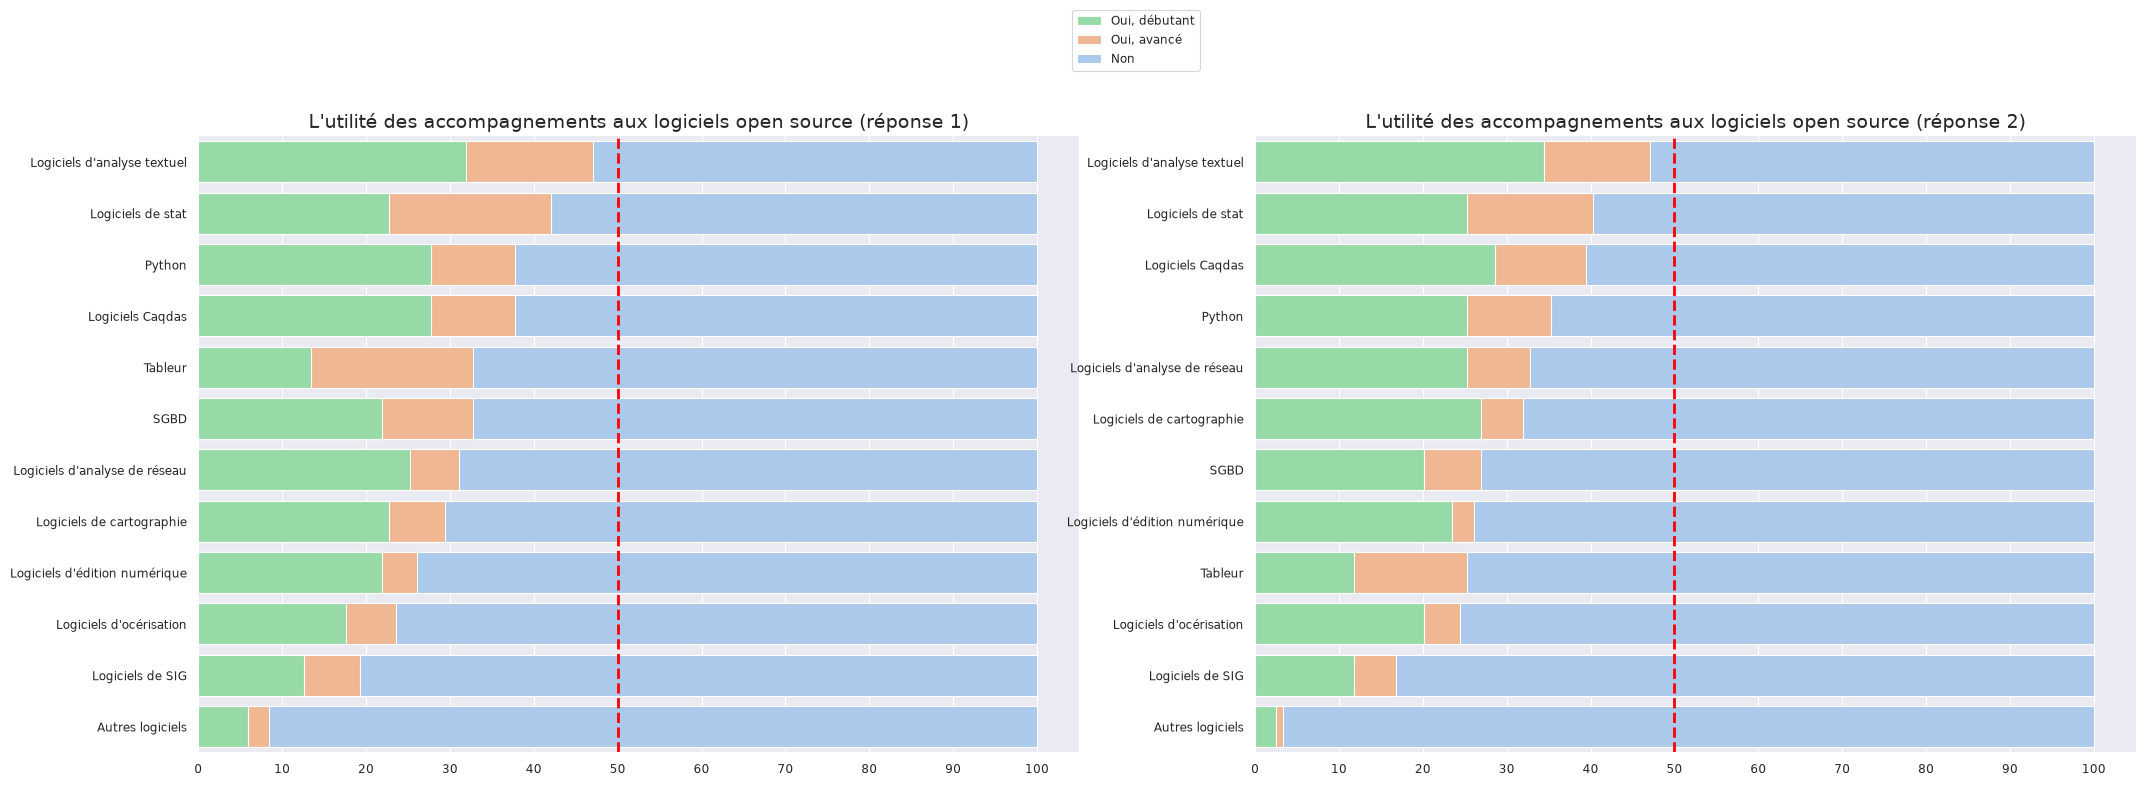

In [48]:
fig, ax = plt.subplots(1,2, figsize=(25,8))

sns.set_theme(style="ticks", context="paper",palette="pastel")

q16_ter["q"] = "q16"
q19_ter["q"] = "q19"
q16_19 = pd.concat([q16_ter, q19_ter])
q16_19["cum_sum"] =q16_19["cum_sum"]*100
for n, col in enumerate(["q16", "q19"]):
    q_data= q16_19.loc[q16_19.q==col]
    g = sns.barplot(x="cum_sum", y="accomp_name", data=q_data, hue="interet_accomp", dodge = False, ax=ax[n])
    
    titre = f"L'utilité des accompagnements aux logiciels open source (réponse {n+1})"


    ax[n].yaxis.set_label_text("")
    ax[n].xaxis.set_label_text("")
    # set the x-axis ticklabel size
    ax[n].set_xticks(ticks = [0,10,20,30,40,50,60,70,80,90,100])
    #ax[n].set_xticks(ticks = [x/10 for x in range(11)])
    #ax[n].set_yticks(fontsize=12)
    ax[n].axvline(x=50, color="red", linestyle="--", linewidth=2)
    ax[n].set_title(titre.replace("<i>","(").replace("</i>",")"), fontsize=14)
    #ax[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
   
    
    sns.despine(left=True, bottom=True)
    ax[n].legend_.remove()

order = [2,1,0]
handles, labels = ax[0].get_legend_handles_labels()
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center', bbox_to_anchor=(0.5, 1))

#plt.savefig(f"./viz/q16_q19_help_outil.png", bbox_inches='tight', dpi = 300)

In [49]:
q16_ter["cum_sum"] =q16_ter["cum_sum"]*100

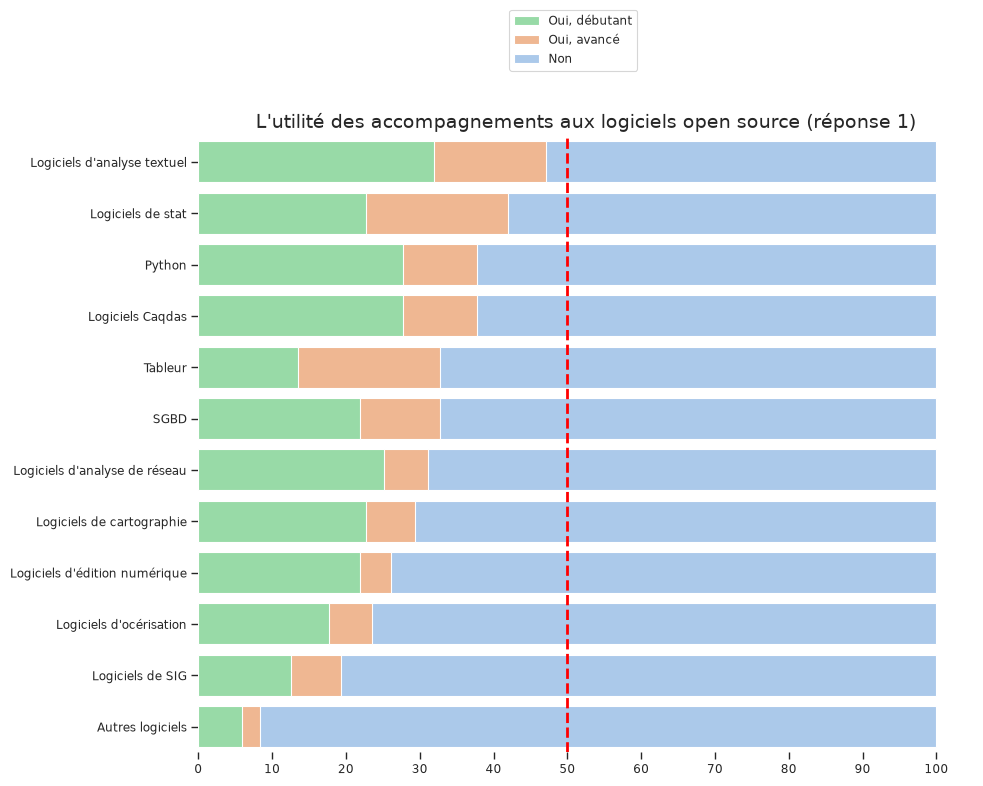

In [82]:
fig, ax = plt.subplots(1, figsize=(10,8))

sns.set_theme(style="ticks", context="paper",palette="pastel")



g = sns.barplot(x="cum_sum", y="accomp_name", data=q16_ter, hue="interet_accomp", dodge = False, ax=ax)
    
titre = f"L'utilité des accompagnements aux logiciels open source (réponse 1)"


ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
# set the x-axis ticklabel size
ax.set_xticks(ticks = [0,10,20,30,40,50,60,70,80,90,100])
#ax[n].set_xticks(ticks = [x/10 for x in range(11)])
#ax[n].set_yticks(fontsize=12)
ax.axvline(x=50, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"), fontsize=14)
#ax[n].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


sns.despine(left=True, bottom=True)
ax.legend_.remove()

order = [2,1,0]
handles, labels = ax.get_legend_handles_labels()
fig.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='center', bbox_to_anchor=(0.5, 1))

plt.savefig(f"./viz/q16_q19_help_outil.png", bbox_inches='tight', dpi = 300)

Les questions concernant les besoins d'accompagnement à différents types de logiciels open source a été posé deux fois :

- question 7, partie "Gestion et traitement des données"
- la question 3 de la partie "Analyse des données".

La comparaison des tris à plat montre que certaines personnes ont répondu différemment. La différence reste néanmoins marginale. Par exemple, la première fois que la question a été posée, 39 personnes ressentaient le besoin d'être accompagné pour utiliser un tableur contre 30 la seconde fois que la question a été posée ({numref}`tableur_comp_1_2`).

```{table} Besoin d'accompagnement pour l'utilisation de tableur: comparaison des réponses 1 et 2
:name: tableur_comp_1_2

| Tableur  |   Réponse 1 |   Réponse 2 |  
|:-------------------|-----:|--------:|
| Non                |   80 |      89 | 
| Oui, avancé        |   23 |      16 | 
| Oui, débutant      |   16 |      14 | 
|Total               |  119 |     119 |
```


Dans l'ensemble, entre 50 et 80% des répondants ne ressentent pas le besoin d'un accompagnement méthodologique pour les différents logiciels cités ({numref}`help_outil`). Les quatre premier types de logiciel demandés sont :

1. les logiciels d'analyse textuelle. 48% des répondants disent ressentir le besoin d'un accompagnement (35% à un niveau débutant et 13% à un niveau avancé). À noter que les logiciels cités renvoient à des approches et des méthodes d'analyse différentes.
2. les logiciel d'analyse statistique (40%)
3. les logiciels d'analyse de données qualitatives, appelés aussi CAQDAS, comme Qualcoder (environ 37%)
4. le langage python (environ 35%)

Ensuite, on observe des besoins d'accompagnement pour les logiciels liés à gestion de bases de données (32%), à l'analyse de réseaux (31%) et la cartographie (29%).

```{figure} ./viz/q16_q19_help_outil.png
:name: help_outil

Besoin d'accompagnement aux outils open source
```


Dans le cas des besoins en accompagnement à la prise en main de logiciels propriétaires, 5 "familles" de logiciels étaient proposées :

- Les tableurs représentés par Excel
- les logiciels de traitements statistiques comme SPSS, Stata, SAS
- les logiciels de traitement des données textuelles avec Atlas.ti
- les systèmes d'information géographique via ArcGis
- les logiciels d'analyse des données qualitative (CAQDAS, Nvivo)

```{figure} ./viz/9_help_outil_proprio.png
:name: help_outil_proprio

Besoin d'accompagnement aux outils propriétaires
```

Excel est l'outil qui obtient le taux le plus élevé : environ 27% des personnes interrogées ressentent le besoin d'être accompagnées. On retrouve une proportion relativement similaire à celles des outils de tableur en open source (25%). En ce qui conerne Nvivo, 23% des répondants sont intéressés par un accompagnement à ce logiciel de la famille des CAQDAS. Cette proportion est inférieure de 14 points à celles des répondants ressentant un besoin d'accompagnement pour les logiciels open source de la même famille. 

Il est toutefois difficile d'interpréter cet écart dans la mesure où les question n'ont pas été rédigées de la même manière ({numref}`question_besoin_help_outil`). La question qui porte sur les logiciels open source est formulée de façon plus générale. Le plus souvent, on parle d'abord de méthodes avant de citer des noms de logiciels. Par exemple, il est écrit "ressentez-vous le besoin d'un accompagnement aux logiciels d'analyse de réseaux (ex. Gephi) ?" Il est possible alors que le besoin ressenti porte autant sur la méthode, c'est-à-dire l'analyse de réseau, que l'outil, qui est ici Gephi. À l'inverse, dans le cas de la question sur les logiciels propriétaires, les noms d'outils sont directement cités sans référence à une méthode particulière.

Il est possible aussi que cet écart soit lié à une fatigue des participants. Ils répondrait alors "non" par facilité, cette case étant cochée par défaut. Néanmoins, nous ne pouvous pas totalement exclure l'hypothèse que les personnes interrogées aient une appétence plus grande pour les logiciels open source que propriétaires. Il nous semble alors intéressant de comparer ces résultats avec ceux du sondage de la DSIN sur le type de suite bureautique (microsoft, google, outils libres) péblicitée par le personnel de l'université. 


```{figure} ./viz/Capture_2026-10-07_16-57-24.jpg
:name: question_besoin_help_outil

Extrait du questionnaire : l'accompagnement aux logiciels open source et propriétaires
        
```

Enfin, une dizaine de répondants ont fait des suggestions d'outils open source ou propriétaires concernant lesquels ils aimeraient être formés. Ces outils s'inscrivent dans les différentes catégories proposées comme "tropy" (analyses de données qualitatives), jamovi (analyse statistique), les bases de données "orientées graphe" (système de gestion de base de données) ou des outils de traitement du son, des textes ou des images.

```{table} Suggestion d'accompagnement à des outils open source ou propriétaire
:name: suggestion_software

| Autres logiciels open source | Autres logiciels propriétaires |
|:-----------------------------|:-------------------------------|
| logiciel d'analyse des gestes, de l'intonation etc.                 | Qualtrics, Jamovi  |
| wikidata                                                            | Photoshop               |
| Logiciel de reconnaissance de texte manuscrits type Transkribus     | Jamovi               |
| modèle linéaire mixte (LMM)                                         |          |
| Bases de données en graphe éventuellement                                                  |        |
| Logiciel de traitement d'entretiens et de vidéos                                           |        |
| Anaconda (python), Tropes...                                                               |    |
| Tropy                                                                                    |  |

```

In [51]:
# COmparaison des fréquences entre les deux séries de questions

for col in df_col.label.loc[(df_col.label.str.contains("q19_"))&(df_col.type=="ordinal")]:
    for name, label in dict_help_outil1.items():  # for name, age in dictionary.iteritems():  (for Python 2.x)
        if label == dict_help_outil2[col]:
            gb_data= grouped_question(df0, column=col, index="q45_clé")
            gb_data2= grouped_question(df0, column=name, index="q45_clé")
            gb_data3 = gb_data2.merge(gb_data.rename(columns={col:name}), on =[name], how = "left")
            gb_data3["diff"] = gb_data3.nb_x - gb_data3.nb_y
           
            print(gb_data3[[name,"diff"]].to_markdown())
            print("------------------------")
            print(gb_data2.to_markdown())
            print("---------------------")
            print(gb_data.to_markdown())
            print("---------------------")
            print("########################")

|    | q16_tableur_help   |   diff |
|---:|:-------------------|-------:|
|  0 | Non                |     -9 |
|  1 | Oui, avancé        |      7 |
|  2 | Oui, débutant      |      2 |
------------------------
|    | q16_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   80 |     119 | 67.2269 |          100 |
|  1 | Oui, avancé        |   23 |     119 | 19.3277 |          100 |
|  2 | Oui, débutant      |   16 |     119 | 13.4454 |          100 |
---------------------
|    | q19_tableur_help   |   nb |   total |    freq |   total_freq |
|---:|:-------------------|-----:|--------:|--------:|-------------:|
|  0 | Non                |   89 |     119 | 74.7899 |          100 |
|  1 | Oui, avancé        |   16 |     119 | 13.4454 |          100 |
|  2 | Oui, débutant      |   14 |     119 | 11.7647 |          100 |
---------------------
########################
|    | q16_logiciels_

In [52]:
for x in df0.q19_1_other_software_help.unique():
    print(x)

nan
wikidata, sparql
Bases de données en graphe
logiciel d'analyse de l'intonation et des gestes sur vidéos
​-


### Outils propriétaires

In [53]:
for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q20_excel_help   |   nb |   total |    freq |   total_freq |
|---:|:-----------------|-----:|--------:|--------:|-------------:|
|  0 | Non              |   86 |     119 | 72.2689 |          100 |
|  1 | Oui, avancé      |   18 |     119 | 15.1261 |          100 |
|  2 | Oui, débutant    |   15 |     119 | 12.605  |          100 |
|    | q20_sas_help   |   nb |   total |      freq |   total_freq |
|---:|:---------------|-----:|--------:|----------:|-------------:|
|  0 | Non            |  110 |     119 | 92.437    |          100 |
|  1 | Oui, avancé    |    1 |     119 |  0.840336 |          100 |
|  2 | Oui, débutant  |    8 |     119 |  6.72269  |          100 |
|    | q20_spss_help   |   nb |   total |     freq |   total_freq |
|---:|:----------------|-----:|--------:|---------:|-------------:|
|  0 | Non             |  112 |     119 | 94.1176  |          100 |
|  1 | Oui, avancé     |    3 |     119 |  2.52101 |          100 |
|  2 | Oui, débutant   |    4 |     119 |  3.361

In [54]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]]

['q20_excel_help',
 'q20_sas_help',
 'q20_spss_help',
 'q20_stata_help',
 'q20_nvivo_help',
 'q20_atlasti_help',
 'q20_oxygen_help',
 'q20_arcgis_help',
 'q20_autre_help']

In [55]:
dict_help_outil_proprio = {
    'q20_excel_help':"Excel",
 'q20_sas_help':"SAS",
 'q20_spss_help':"SPSS",
 'q20_stata_help':"STATA",
 'q20_nvivo_help':"Nvivo",
 'q20_atlasti_help':"Atlas.ti",
 'q20_oxygen_help':"Oxygen",
 'q20_arcgis_help':"Arcgis",
 'q20_autre_help':"Autres"}



In [56]:

i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q20_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_help_outil_proprio[col]


    if i == 0:
        q20 = dftmp.copy()
    else:
        q20 = pd.concat([q20, dftmp])


In [57]:
q20_bis = pd.crosstab(q20.accomp_name, q20.interet_accomp, normalize="index").stack().reset_index(name='nb')
q20_ter =  pd.crosstab(q20.accomp_name, q20.interet_accomp, normalize="index")
q20_ter = q20_ter[['Oui, débutant','Oui, avancé','Non']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [58]:
q20_ter = q20_ter.merge(q20_bis, on=["accomp_name","interet_accomp"], how = "left")

In [59]:
for x in q20_ter.accomp_name.unique():
    non = q20_ter.nb.loc[(q20_ter.accomp_name==x) & (q20_ter.interet_accomp=="Non")]
    q20_ter.loc[q20_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q20_ter = q20_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q20_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
17,Excel,Non,1.000000,0.722689,0.277311
16,Excel,"Oui, avancé",0.277311,0.151261,0.277311
15,Excel,"Oui, débutant",0.126050,0.126050,0.277311
14,Nvivo,Non,1.000000,0.773109,0.226891
13,Nvivo,"Oui, avancé",0.226891,0.075630,0.226891
12,Nvivo,"Oui, débutant",0.151261,0.151261,0.226891
2,STATA,Non,1.000000,0.907563,0.092437
1,STATA,"Oui, avancé",0.092437,0.008403,0.092437
0,STATA,"Oui, débutant",0.084034,0.084034,0.092437
23,Atlas.ti,Non,1.000000,0.907563,0.092437


In [60]:
q20_ter["cum_sum"] = q20_ter["cum_sum"]*100

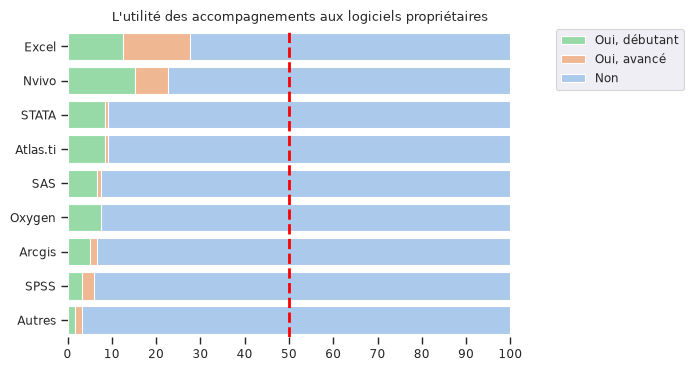

In [61]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(context="paper", palette="pastel")


g = sns.barplot(x="cum_sum", y="accomp_name", data=q20_ter, hue="interet_accomp", dodge=False)

titre = "L'utilité des accompagnements aux logiciels propriétaires"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [0,10,20,30,40,50,60,70,80,90,100])
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.axvline(x=50, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot


ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/9_help_outil_proprio.png", bbox_inches='tight', dpi = 200)

In [62]:
df0.loc[df0.q20_nvivo_help=="Non", "Nvivo"] ="NON"
df0.loc[df0.q20_nvivo_help!="Non", "Nvivo"] ="Oui"
df0.loc[df0.q19_caqdas_help=="Non", "CAQDAS_os"] ="NON"
df0.loc[df0.q19_caqdas_help!="Non", "CAQDAS_os"] ="Oui"

In [63]:
print(pd.crosstab(df0.Nvivo, df0.CAQDAS_os, normalize=False, margins=True).to_markdown())

| Nvivo   |   NON |   Oui |   All |
|:--------|------:|------:|------:|
| NON     |    66 |    26 |    92 |
| Oui     |     6 |    21 |    27 |
| All     |    72 |    47 |   119 |


In [64]:
for x in df0.q16_1_other_software_help.loc[~df0.q16_1_other_software_help.isna()]:
    print(x)

Logiciel de traitement d'entretiens et de vidéos 
modèle linéaire mixte (LMM)
wikidata
Tropy
Comme je ne connais pas certains de ces logiciels, je ne sais pas s'ils me seraient utiles
Bases de données en graphe éventuellement
logiciel d'analyse des gestes, de l'intonation etc.
Logiciel de reconnaissance de texte manuscrits type Transkribus
Anaconda (python), Tropes...
​-


In [65]:
for x in df0.q19_1_other_software_help.loc[~df0.q19_1_other_software_help.isna()]:
    print(x)

wikidata, sparql
Bases de données en graphe
logiciel d'analyse de l'intonation et des gestes sur vidéos
​-


In [66]:
df01 = df0[["q45_clé","q16_1_other_software_help"]].loc[~df0.q16_1_other_software_help.isna()].merge(df0[["q45_clé","q19_1_other_software_help"]].loc[~df0.q19_1_other_software_help.isna()], on=["q45_clé"], how="left")
df01

,q45_clé,q16_1_other_software_help,q19_1_other_software_help
0,FCCB-GMYA,Logiciel de traitement d'entretiens et de vidéos,NaN
1,9K9T-RVNL,modèle linéaire mixte (LMM),NaN
2,5G5M-BM3L,wikidata,"wikidata, sparql"
3,YL4Q-KQAK,Tropy,NaN
4,ZB5S-ABHN,Comme je ne connais pas certains de ces logici...,NaN
5,DBQD-JQTW,Bases de données en graphe éventuellement,Bases de données en graphe
6,3V5K-8FEA,"logiciel d'analyse des gestes, de l'intonation...",logiciel d'analyse de l'intonation et des gest...
7,82N2-HDNU,Logiciel de reconnaissance de texte manuscrits...,NaN
8,X48K-M3K4,"Anaconda (python), Tropes...",NaN
9,32TW-JLY5,​-,​-


In [67]:
for x in df0.q20_1_other_closed_software_help.loc[~df0.q20_1_other_closed_software_help.isna()]:
    print(x)

Photoshop 
Jamovi : c'est ce logiciel qu'on utilise avec les étudiants car il est gratuit et très facile à utiliser. Il propose de nombreux modules pour lesquels ils seraient intéressant d'être formé afin d'améliorer le niveau de notre expertise par rapport au logiciel
Qualtrics, Jamovi
​-


In [68]:
print(df0[["q45_clé","q16_1_other_software_help"]].loc[~df0.q16_1_other_software_help.isna()].merge(df0[["q45_clé", "q20_1_other_closed_software_help"]].loc[~df0.q20_1_other_closed_software_help.isna()], on =["q45_clé"], how="outer").drop(columns=["q45_clé"]).to_markdown(index=False))

| q16_1_other_software_help                                                                  | q20_1_other_closed_software_help                                                                                                                                                                                                                                   |
|:-------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ​-                                                                                          | ​-                                                                                                                                                                                              

### Services à développer

In [69]:
for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]:
    gb_data= grouped_question(df0, column=col, index="q45_clé")
    print(gb_data.to_markdown())

|    | q22_postes_info   |   nb |   total |    freq |   total_freq |
|---:|:------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile    |   42 |     119 | 35.2941 |          100 |
|  1 | Oui, plutôt utile |   50 |     119 | 42.0168 |          100 |
|  2 | Oui, très utile   |   27 |     119 | 22.6891 |          100 |
|    | q22_ressources_doc   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile       |   19 |     119 | 15.9664 |          100 |
|  1 | Oui, plutôt utile    |   62 |     119 | 52.1008 |          100 |
|  2 | Oui, très utile      |   38 |     119 | 31.9328 |          100 |
|    | q22_working_spaces   |   nb |   total |    freq |   total_freq |
|---:|:---------------------|-----:|--------:|--------:|-------------:|
|  0 | Non, pas utile       |   20 |     119 | 16.8067 |          100 |
|  1 | Oui, plutôt utile    |   54 |     119 | 45.3782 |          100 |
|  2 | 

In [70]:
[col for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]]

['q22_postes_info',
 'q22_ressources_doc',
 'q22_working_spaces',
 'q22_permanences',
 'q22_sdbox_casd']

In [71]:
dict_services_utiles = {
    'q22_postes_info':"Postes informatiques",
 'q22_ressources_doc':"Ressources documentaires",
 'q22_working_spaces':"Espaces de travail",
 'q22_permanences':"Permanences d'accueil",
 'q22_sdbox_casd':"Accès SdBox et CASD"}



In [72]:
i=-1
for col in df_col.label.loc[(df_col.label.str.contains("q22_"))&(df_col.type=="ordinal")]:
    i+=1
    dftmp = df0[["q45_clé", col]].rename(columns={col:"interet_accomp"})
    dftmp["accomp_name"]= dict_services_utiles[col]


    if i == 0:
        q22 = dftmp.copy()
    else:
        q22 = pd.concat([q22, dftmp])

In [73]:
q22_bis = pd.crosstab(q22.accomp_name, q22.interet_accomp, normalize="index").stack().reset_index(name='nb')
q22_ter =  pd.crosstab(q22.accomp_name, q22.interet_accomp, normalize="index")
q22_ter = q22_ter[['Oui, plutôt utile','Oui, très utile','Non, pas utile']].cumsum(axis=1).stack().reset_index(name='cum_sum').sort_values(by=["accomp_name","interet_accomp"],ascending=[False, False])


In [74]:
q22_ter = q22_ter.merge(q22_bis, on=["accomp_name","interet_accomp"], how = "left")

In [75]:
q22_ter

,accomp_name,interet_accomp,cum_sum,nb
0,Ressources documentaires,"Oui, très utile",0.840336,0.319328
1,Ressources documentaires,"Oui, plutôt utile",0.521008,0.521008
2,Ressources documentaires,"Non, pas utile",1.000000,0.159664
3,Postes informatiques,"Oui, très utile",0.647059,0.226891
4,Postes informatiques,"Oui, plutôt utile",0.420168,0.420168
5,Postes informatiques,"Non, pas utile",1.000000,0.352941
6,Permanences d'accueil,"Oui, très utile",0.806723,0.411765
7,Permanences d'accueil,"Oui, plutôt utile",0.394958,0.394958
8,Permanences d'accueil,"Non, pas utile",1.000000,0.193277
9,Espaces de travail,"Oui, très utile",0.831933,0.378151


In [76]:
for x in q22_ter.accomp_name.unique():
    non = q22_ter.nb.loc[(q22_ter.accomp_name==x) & (q22_ter.interet_accomp=="Non, pas utile")]
    q22_ter.loc[q22_ter.accomp_name==x, "Oui"] = 1- np.sum(non)
q22_ter = q22_ter.sort_values(["Oui","accomp_name","cum_sum"],  ascending=[False, False, False])
q22_ter

,accomp_name,interet_accomp,cum_sum,nb,Oui
2,Ressources documentaires,"Non, pas utile",1.000000,0.159664,0.840336
0,Ressources documentaires,"Oui, très utile",0.840336,0.319328,0.840336
1,Ressources documentaires,"Oui, plutôt utile",0.521008,0.521008,0.840336
11,Espaces de travail,"Non, pas utile",1.000000,0.168067,0.831933
9,Espaces de travail,"Oui, très utile",0.831933,0.378151,0.831933
10,Espaces de travail,"Oui, plutôt utile",0.453782,0.453782,0.831933
8,Permanences d'accueil,"Non, pas utile",1.000000,0.193277,0.806723
6,Permanences d'accueil,"Oui, très utile",0.806723,0.411765,0.806723
7,Permanences d'accueil,"Oui, plutôt utile",0.394958,0.394958,0.806723
5,Postes informatiques,"Non, pas utile",1.000000,0.352941,0.647059


In [77]:
q22_ter["cum_sum"] = q22_ter["cum_sum"]*100

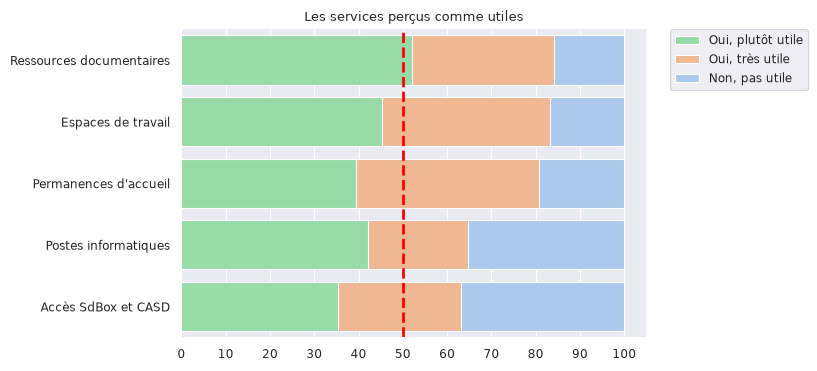

In [78]:
fig, ax = plt.subplots(1, figsize=(6,4))

sns.set_theme(context="paper", palette="pastel")


   
g = sns.barplot(x="cum_sum", y="accomp_name", data=q22_ter, hue="interet_accomp", dodge=False)

titre = "Les services perçus comme utiles"
ax.yaxis.set_label_text("")
ax.xaxis.set_label_text("")
ax.set_xticks(ticks = [0,10,20,30,40,50,60,70,80,90,100])
#ax.set_xticks(ticks = [x/10 for x in range(11)])
ax.axvline(x=50, color="red", linestyle="--", linewidth=2)
ax.set_title(titre.replace("<i>","(").replace("</i>",")"))

handles, labels = plt.gca().get_legend_handles_labels()
order = [2,1,0]

#add legend to plot
#plt.legend() 
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1),
                         loc='upper left', borderaxespad=0.)

sns.despine(left=True, bottom=True)
plt.savefig(f"./viz/11_ressources.png", bbox_inches='tight', dpi = 200)

In [79]:
for x in df0.q23_other_service_univ.loc[~df0.q23_other_service_univ.isna()]:
    print("####\n",x)
    

####
 Non 
####
 DE quoi déposer et échanges des données en toute confidentialité et selon les règles imposées par le CNRS notamment
####
 je n' y ai pas suffisamment songé
####
 Certaines université américaines ont des partenariats avec des éditeurs, qui leur permet de valoriser leurs travaux en publiant gratuitement en open access. Pourrait-on avoir ce service ? 
####
 service dans les labos
####
 non
####
 Je ne connais pas le CASD
####
 Apprendre à coder avec l'IA sans devenir soi-même développeur : donc un accès personnalisé à des développeurs (notamment en Python), comme une permanence d'accueil à créneaux fixes
####
 je ne sais pas
####
 Quand je parle de documentation je parle d'ouvrages pour la recherche la bibliothèque étant très loin d'être au niveau sur cet aspect même si elle a un bon.fonds pour la formation... idem pour les salles de réunion ou de travail il y a eu un espace avanius avons b
####
 La possibilité de créer des accès wifi pour les stagiaires et les nouveaux c

L'enquête proposait une liste de services en demandant aux participants s'ils considéraient comme utile de les développer. 83% des répondants trouvent ainsi qu'il serait utile de développer les ressources documentaires. Deux d'entre eux écrivent : 

> "Quand je parle de documentation, je parle d'ouvrages pour la recherche. La bibliothèque est très loin d'être au niveau sur cet aspect, même si elle a un bon fond pour la formation."

> "Il est certain que les ressources documentaires de la bibliothèque sont très pauvres en ce qui concerne la recherche et ne peuvent être utilisées, à mon sens, par des chercheurs d'aujourd'hui."

On observe des taux équivalents de participants intéressés par le dévloppement d'espaces de travail (83%) ou d'une permanence (81%). Là aussi, un des répondants precise le type de service qui devrait être mis en place : 

> Apprendre à coder avec l'IA sans devenir soi-même développeur : donc un accès personnalisé à des développeurs (notamment en Python), comme une permanence d'accueil à créneaux fixes.

Le service ayant le moins de succès concerne l'accès à une {term}`SD-Box` et au CASD (Centre d'accès sécurisé aux données). 63% des répondants le jugent tout de même utile.


```{figure} ./viz/11_ressources.png
:name: 11_service_to_develop

Les services à développer
```

Pour compléter une question ouverte permettait aux participants de suggérer le développement d'autres services. Quinze personnes y ont répondu. Les propositions portent sur :

- l'accès à des bureaux nominatifs et équipés informatiquement
- des accès wifi pour les stagiaires et les nouveaux collègues dans "un délai raisonnable"
- le développement de services liés à la sécurité des données (accès à un serveur chiffré et des lieux de stockages sécurisés)
- des formations sur l'éthique de la recherche.